In [39]:
from core.validation import get_valid_image_number
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from numpy import ndarray
import cv2 as cv
import numpy as np
import os


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
numpy_folder: str = os.getenv("NUMPY_FOLDER")

# Define numpy file path
img_number: str = get_valid_image_number()
numpy_file_path: str = os.path.join(numpy_folder, f"{img_number}.npy")

# Load numpy file
numpy_file = np.load(numpy_file_path)

Forma da imagem recuperada: (512, 910, 3)


(np.float64(-0.5), np.float64(909.5), np.float64(511.5), np.float64(-0.5))

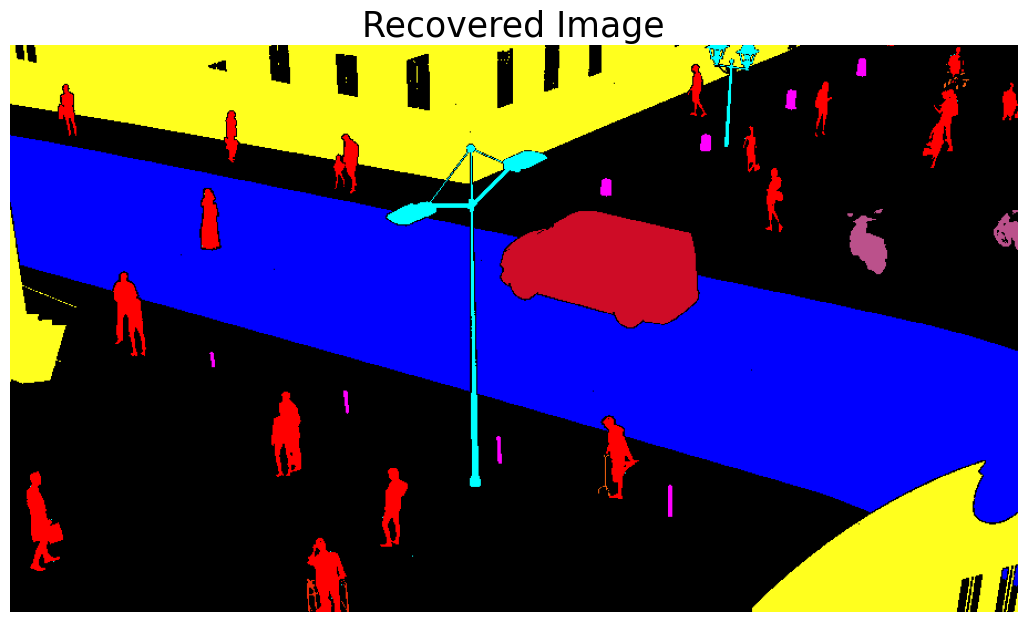

In [40]:
# I need improve this color map in the future
color_map = [
    (0, 255, 255),      # Aqua Color
    (241, 145, 79),     # Aquamarine Color
    (0, 0, 255),        # Blue Color
    (255, 0, 255),      # Fuchsia Color
    (0, 255, 0),        # Green Color
    (241, 94, 20),      # Light Amber Color
    (235, 124, 115),    # Light Blue Violet Color
    (236, 73, 106),     # Light Blue Color
    (235, 42, 9),       # Light Coral Color
    (206, 12, 38),      # Light Gray Color
    (252, 88, 26),      # Light Khaki Color
    (235, 130, 47),     # Light Olive Color
    (236, 95, 15),      # Light Orange Color
    (255, 111, 74),     # Light Teal Color
    (187, 81, 139),     # Medium Purple Color
    (254, 60, 86),      # Pale Aqua Color
    (255, 0, 0),        # Red Color
    (255, 255, 30)      # Yellow Color
]

def reconstruct_image(npy_file: str):
    combined_mask = np.load(npy_file)

    h, w, _ = combined_mask.shape
    reconstructed_img = np.zeros((h, w, 3), dtype=np.uint8) # Black background
    # reconstructed_img = np.full((h, w, 3), fill_value=255, dtype=np.uint8) # White background, i need improve this in the future

    for i in range(combined_mask.shape[2]):
        mask = combined_mask[:, :, i]
        color_layer = np.zeros_like(reconstructed_img)
        color_layer[mask == 255] = color_map[i]
        # cv.add() vs np.sum(): cv.add() is better
        # https://docs.opencv.org/4.x/d0/d86/tutorial_py_image_arithmetics.html
        reconstructed_img = cv.add(reconstructed_img, color_layer)
        # OpenCV: BGR to RGB
        reversed_img_channels = reconstructed_img[:, :, ::-1]

    return reversed_img_channels

recovered_image = reconstruct_image(numpy_file_path)

# Old Plot
# plt.imshow(recovered_image, interpolation="antialiased")
# plt.show()

# New Setup Plot
import cv2 as cv
# Base Path for image folder
recovered_img_folder: str = os.getenv("RECOVERED_IMG_FOLDER")
print(f"Forma da imagem recuperada: {recovered_image.shape}")
# Plotting binary mask
plt.figure(figsize=[13,13])
plt.imshow(recovered_image[:, :, ::-1])
plt.title("Recovered Image",fontdict={'fontsize': 25})
output_file: str = os.path.join(recovered_img_folder, f"recovered_img_with_colors_{img_number}.png")
cv.imwrite(output_file, recovered_image)
plt.axis('off')